In [1]:
# ============================================================
# 📦 Import Library
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [2]:
# ============================================================
# 📥 Membaca Dataset Excel
# ============================================================

file_path = "Book45.xlsx"  # ganti jika nama file berbeda
df = pd.read_excel(file_path)

print("Jumlah baris dan kolom:", df.shape)
display(df.head())

Jumlah baris dan kolom: (186715, 26)


,Time,voltage,current,cell 1,cell 2,cell 3,cell 4,cell 5,cell 6,cell 7,...,cell 14,cell 15,cell 16,temp 1,temp 2,temp 3,temp 4,SOC,SOH,Acc. voltage(V)
0,2024/10/2 23:54:19,53.0,-206.1,3318.0,3316.0,3316.0,3318.0,3316.0,3318.0,3316.0,...,3315.0,3311.0,3314.0,42.0,44.0,43.0,44.0,70.4,99.5,53.0
1,2024/10/2 23:54:24,53.0,-66.6,3318.0,3315.0,3316.0,3318.0,3316.0,3318.0,3315.0,...,3315.0,3310.0,3313.0,42.0,44.0,43.0,44.0,70.4,99.5,53.0
2,2024/10/2 23:54:29,53.0,-42.9,3318.0,3315.0,3315.0,3317.0,3315.0,3317.0,3314.0,...,3314.0,3309.0,3310.0,42.0,44.0,43.0,44.0,70.4,99.5,53.0
3,2024/10/2 23:54:34,53.0,-76.3,3317.0,3316.0,3315.0,3317.0,3315.0,3317.0,3315.0,...,3314.0,3309.0,3311.0,42.0,44.0,43.0,44.0,70.4,99.5,53.0
4,2024/10/2 23:54:39,53.0,-79.9,3318.0,3316.0,3315.0,3318.0,3315.0,3317.0,3315.0,...,3315.0,3309.0,3311.0,42.0,44.0,43.0,44.0,70.4,99.5,53.0


In [3]:
# ============================================================
# 🧼 Pemeriksaan Missing Value
# ============================================================

print("Jumlah missing value per kolom:")
print(df.isnull().sum())

# Hapus baris yang mengandung nilai kosong (jika ada)
df = df.dropna()
print("Setelah pembersihan:", df.shape)


Jumlah missing value per kolom:
Time               11
voltage            11
current            11
cell 1             11
cell 2             11
cell 3             11
cell 4             11
cell 5             11
cell 6             11
cell 7             11
cell 8             11
cell 9             11
cell 10            11
cell 11            11
cell 12            11
cell 13            11
cell 14            11
cell 15            11
cell 16            11
temp 1             14
temp 2             14
temp 3             14
temp 4             14
SOC                 0
SOH                 0
Acc. voltage(V)     0
dtype: int64
Setelah pembersihan: (186701, 26)


In [4]:
# ============================================================
# 🎯 Tentukan Fitur dan Target (Versi Aman & Otomatis)
# ============================================================

# Deteksi kolom yang mengandung data waktu (datetime atau string dengan format waktu)
time_like_cols = [
    col for col in df.columns 
    if any(key in col.lower() for key in ['time', 'tanggal', 'waktu', 'date', 'timestamp'])
]

print("Kolom waktu terdeteksi:", time_like_cols)

# Drop kolom waktu kalau ada
df = df.drop(columns=time_like_cols, errors='ignore')

# Asumsi kolom terakhir adalah SoC
features = df.columns[:-1]
target = df.columns[-1]

# Hanya ambil kolom numerik agar tidak error di scaler
X = df[features].select_dtypes(include=[np.number]).values
y = df[target].values.reshape(-1, 1)

print("Kolom fitur yang digunakan:", list(features))
print("Target:", target)
print("Dimensi X:", X.shape, " | Dimensi y:", y.shape)


Kolom waktu terdeteksi: ['Time']
Kolom fitur yang digunakan: ['voltage', 'current', 'cell 1', 'cell 2', 'cell 3', 'cell 4', 'cell 5', 'cell 6', 'cell 7', 'cell 8', 'cell 9', 'cell 10', 'cell 11', 'cell 12', 'cell 13', 'cell 14', 'cell 15', 'cell 16', 'temp 1', 'temp 2', 'temp 3', 'temp 4', 'SOC', 'SOH']
Target: Acc. voltage(V)
Dimensi X: (186701, 24)  | Dimensi y: (186701, 1)


In [5]:
# ============================================================
# 🔄 Normalisasi (Scaling)
# ============================================================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

print("Contoh data hasil scaling:")
print(X_scaled[:3])


Contoh data hasil scaling:
[[0.16949153 0.20462046 0.16410256 0.16452442 0.16581633 0.16883117
  0.16795866 0.16795866 0.24738676 0.23469388 0.2        0.16169154
  0.15763547 0.15815085 0.15686275 0.15158924 0.25407166 0.23076923
  0.70588235 0.73684211 0.70588235 0.66666667 0.67184035 1.        ]
 [0.16949153 0.47544166 0.16410256 0.16195373 0.16581633 0.16883117
  0.16795866 0.16795866 0.24390244 0.23469388 0.19701493 0.16169154
  0.15763547 0.15815085 0.15686275 0.15158924 0.25081433 0.22792023
  0.70588235 0.73684211 0.70588235 0.66666667 0.67184035 1.        ]
 [0.16949153 0.52145215 0.16410256 0.16195373 0.16326531 0.16623377
  0.16537468 0.16537468 0.24041812 0.23129252 0.19701493 0.15920398
  0.15517241 0.15571776 0.15196078 0.14914425 0.247557   0.21937322
  0.70588235 0.73684211 0.70588235 0.66666667 0.67184035 1.        ]]


In [6]:
# ============================================================
# ✂️ Split Data
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

print(f"Train set: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train set: (130690, 24), Validation: (28005, 24), Test: (28006, 24)


In [7]:
# ============================================================
# 🔢 Ubah ke Bentuk 3D: [samples, timesteps, features]
# ============================================================

X_train = np.expand_dims(X_train, axis=1)
X_val = np.expand_dims(X_val, axis=1)
X_test = np.expand_dims(X_test, axis=1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (130690, 1, 24)
y_train shape: (130690, 1)


In [8]:
# ============================================================
# 🧠 Model CNN + LSTM Ringan
# ============================================================

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(32, kernel_size=1, activation='relu'),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse'
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 1, 32)             800       
                                                                 
 lstm (LSTM)                 (None, 32)                8320      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 9,665
Trainable params: 9,665
Non-trainable params: 0
_________________________________________________________________


In [9]:
# ============================================================
# ⚙️ Callback
# ============================================================

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)


In [10]:
# ============================================================
# 🚀 Training Model
# ============================================================

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,  # efisien untuk VRAM 2GB
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)


Epoch 1/100
2043/2043 - 39s - loss: 0.0071 - val_loss: 2.7264e-04 - lr: 1.0000e-04 - 39s/epoch - 19ms/step
Epoch 2/100
2043/2043 - 23s - loss: 7.1575e-04 - val_loss: 3.3515e-04 - lr: 1.0000e-04 - 23s/epoch - 11ms/step
Epoch 3/100
2043/2043 - 22s - loss: 4.7215e-04 - val_loss: 4.6897e-04 - lr: 1.0000e-04 - 22s/epoch - 11ms/step
Epoch 4/100
2043/2043 - 22s - loss: 3.5860e-04 - val_loss: 4.5764e-04 - lr: 1.0000e-04 - 22s/epoch - 11ms/step
Epoch 5/100
2043/2043 - 23s - loss: 2.9696e-04 - val_loss: 5.5086e-04 - lr: 1.0000e-04 - 23s/epoch - 11ms/step
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
2043/2043 - 22s - loss: 2.6389e-04 - val_loss: 4.9272e-04 - lr: 1.0000e-04 - 22s/epoch - 11ms/step
Epoch 7/100
2043/2043 - 22s - loss: 2.4003e-04 - val_loss: 5.5209e-04 - lr: 5.0000e-05 - 22s/epoch - 11ms/step
Epoch 8/100
2043/2043 - 22s - loss: 2.3144e-04 - val_loss: 5.2435e-04 - lr: 5.0000e-05 - 22s/epoch - 11ms/step
Epoch 9/100
2043/2043 - 22s - loss: 2.2

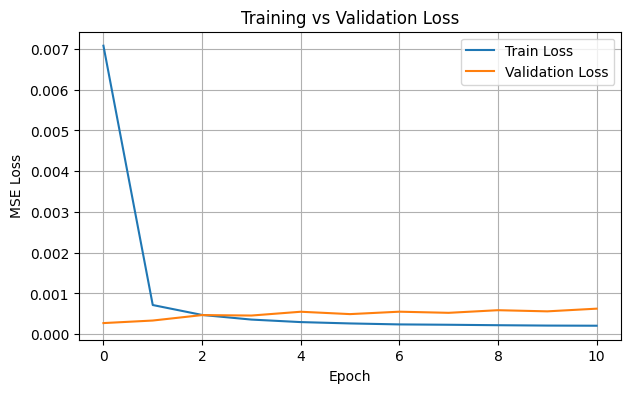

In [11]:
# ============================================================
# 📊 Grafik Training vs Validation Loss
# ============================================================

plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


876/876 [==============================] - 7s 8ms/step


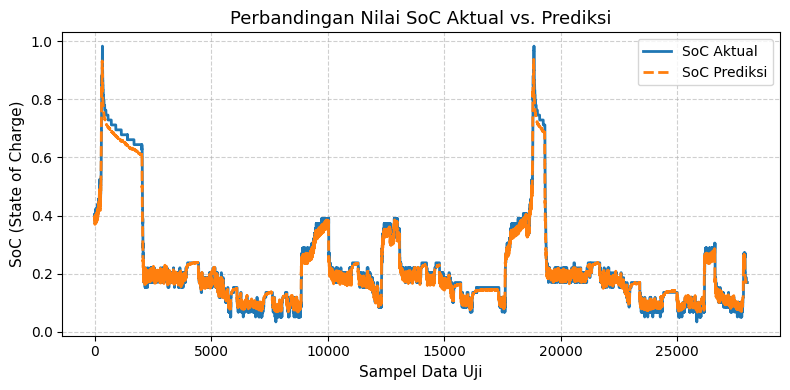

Gambar 3. Perbandingan Nilai SoC Aktual vs. Prediksi. Kurva prediksi hampir sepenuhnya menutupi kurva aktual, menunjukkan kesalahan yang minimal.


In [20]:
# 📈 Perbandingan Nilai SoC Aktual vs Prediksi
import matplotlib.pyplot as plt

# Prediksi model
y_pred = model.predict(X_test).flatten()
y_true = y_test.flatten()

# Plot hasil prediksi vs aktual
plt.figure(figsize=(8, 4))
plt.plot(y_true, label='SoC Aktual', linewidth=2)
plt.plot(y_pred, label='SoC Prediksi', linestyle='--', linewidth=2)
plt.title('Perbandingan Nilai SoC Aktual vs. Prediksi', fontsize=13)
plt.xlabel('Sampel Data Uji', fontsize=11)
plt.ylabel('SoC (State of Charge)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# Caption otomatis seperti di laporan LaTeX
print("Gambar 3. Perbandingan Nilai SoC Aktual vs. Prediksi. "
      "Kurva prediksi hampir sepenuhnya menutupi kurva aktual, menunjukkan kesalahan yang minimal.")


In [12]:
# ============================================================
# 📈 Evaluasi Model pada Data Test
# ============================================================

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")


876/876 [==============================] - 8s 8ms/step
MSE: 0.0124
R²: 0.9870


876/876 [==============================] - 8s 9ms/step
Label yang muncul di data uji: [0 1 2 3 4]


<Figure size 600x500 with 0 Axes>

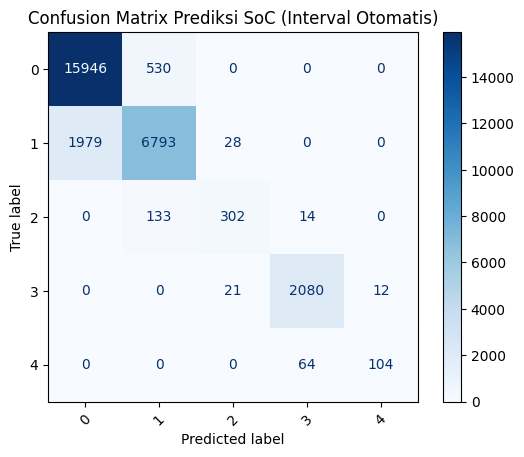


📈 Metrik Evaluasi Prediksi SoC (berdasarkan interval):
Akurasi  : 0.9007
Presisi  : 0.9015
Recall   : 0.9007
F1-Score : 0.8980

📋 Laporan Klasifikasi per Kelas:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     16476
           1       0.91      0.77      0.84      8800
           2       0.86      0.67      0.76       449
           3       0.96      0.98      0.97      2113
           4       0.90      0.62      0.73       168

    accuracy                           0.90     28006
   macro avg       0.90      0.80      0.84     28006
weighted avg       0.90      0.90      0.90     28006



In [19]:
# 📊 Confusion Matrix + Metrik Evaluasi
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Prediksi dan konversi ke kelas (misal 5 interval SoC)
num_classes = 5
y_pred = model.predict(X_test).flatten()
y_true = y_test.flatten()

# Buat batas interval antara 0–1 (misal SoC dinormalisasi)
bins = np.linspace(0, 1, num_classes + 1)
y_true_cls = np.digitize(y_true, bins) - 1
y_pred_cls = np.digitize(y_pred, bins) - 1

# 2️⃣ Pastikan label unik di kedua array
labels_used = np.unique(np.concatenate([y_true_cls, y_pred_cls]))
print(f"Label yang muncul di data uji: {labels_used}")

# 3️⃣ Buat confusion matrix dengan label dinamis
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=labels_used)

# 4️⃣ Visualisasi confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_used)
plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix Prediksi SoC (Interval Otomatis)")
plt.show()

# 5️⃣ Hitung metrik evaluasi
acc = accuracy_score(y_true_cls, y_pred_cls)
prec = precision_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)
rec = recall_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)
f1 = f1_score(y_true_cls, y_pred_cls, average='weighted', zero_division=0)

print("\n📈 Metrik Evaluasi Prediksi SoC (berdasarkan interval):")
print(f"Akurasi  : {acc:.4f}")
print(f"Presisi  : {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# 6️⃣ (Opsional) Lihat detail tiap kelas
print("\n📋 Laporan Klasifikasi per Kelas:")
print(classification_report(y_true_cls, y_pred_cls, zero_division=0))


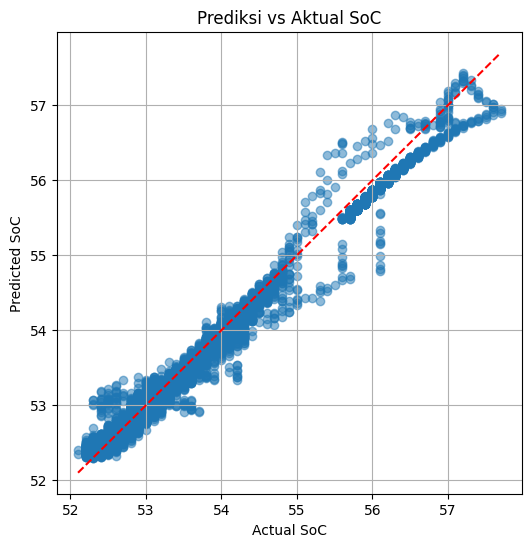

In [13]:
# ============================================================
# 📉 Plot Prediksi vs Aktual SoC
# ============================================================

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("Actual SoC")
plt.ylabel("Predicted SoC")
plt.title("Prediksi vs Aktual SoC")
plt.grid(True)
plt.show()
